# Avito Bootcamp NLP: кандидатогенерация для поиска услуг

**Задача:** по поисковому запросу вернуть до 50 объявлений так, чтобы в них попали те, что пользователь в итоге выбрал. Метрика — Recall@50.

**Итог:** Recall@50 = **0.899** на бенчмарке (отправка 5). Бейзлайн BM25 + локация давал 0.809.

Ноутбук — сопровождение к коду в репозитории: он показывает ключевые наблюдения по данным, как устроена валидация, что дал каждый шаг и какие ошибки остались. Последний раздел воспроизводит финальный `answer.csv`.

Тяжёлые шаги (лемматизация корпуса, эмбеддинги, признаки) кэшируются в `cache/`; первый запуск с нуля занимает несколько часов на ноутбуке, повторный — минуты. Подробности — в `Readme.md`.

In [1]:
import hashlib, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_bench_items, load_bench_queries, load_train
from src.validation import build_hard_corpus, load_split

pd.set_option("display.max_colwidth", 80)
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"

Matplotlib is building the font cache; this may take a moment.


## 1. Данные: что оказалось важным

Три файла: `train.parquet` (пары «запрос — выбранное объявление»), `benchmark_queries.parquet` (2452 запроса без разметки) и `benchmark_items.parquet` (корпус из 189k объявлений).

In [2]:
train = load_train(columns=["search_query", "search_location_id", "search_category",
                            "item_id", "item_category_id", "item_location_id"])
bq = load_bench_queries()
bi = load_bench_items(columns=["item_id", "item_location_id"])
print(f"train: {len(train):,} строк, {train.search_query.nunique():,} уникальных запросов, {train.item_id.nunique():,} объявлений")
print(f"бенчмарк: {len(bq):,} запросов (уникальных текстов: {bq.search_query.nunique():,}), корпус {len(bi):,} объявлений")
print(f"доля строк train с категорией 114 (услуги): поиск {(train.search_category == 114).mean():.4f}, объявление {(train.item_category_id == 114).mean():.4f}")
print(f"тексты бенчмарка, встречающиеся в train: {bq.search_query.isin(set(train.search_query)).mean():.1%}")
print(f"объявления корпуса, встречающиеся в train: {bi.item_id.isin(set(train.item_id)).mean():.1%}")

train: 497,673 строк, 74,529 уникальных запросов, 344,825 объявлений
бенчмарк: 2,452 запросов (уникальных текстов: 2,452), корпус 189,212 объявлений
доля строк train с категорией 114 (услуги): поиск 0.9999, объявление 1.0000


тексты бенчмарка, встречающиеся в train: 37.0%


объявления корпуса, встречающиеся в train: 9.6%


**Выводы:**
* **Категория бесполезна:** почти всё — 114 («услуги»). Полезна только подкатегория `item_microcat_id`.
* Бенчмарк — это выборка **уникальных** запросов; 37% их текстов встречались в train. Валидация должна повторять эту смесь.
* Только ~10% объявлений корпуса есть в train, поэтому train годится для обучения сигналов, а не как «словарь ответов».

In [3]:
corpus_locs = set(bi.item_location_id)
city = train.search_location_id.isin(corpus_locs)
same = train.search_location_id == train.item_location_id
print(f"объявление из той же локации, что и поиск: {same.mean():.1%} всех строк")
print(f"  если локация поиска — город (есть в корпусе): {same[city].mean():.1%}")
print(f"  если локация поиска — регион/страна:         {same[~city].mean():.1%}")
print(f"запросы бенчмарка с локацией-регионом (её нет в корпусе): {(~bq.search_location_id.isin(corpus_locs)).mean():.1%}")
top = train[train.search_location_id == 107620].item_location_id.value_counts(normalize=True).head(3)
print("пример: поиск в 107620 (Московская обл.) -> локации выбранных объявлений:", top.round(2).to_dict())

объявление из той же локации, что и поиск: 83.1% всех строк
  если локация поиска — город (есть в корпусе): 93.3%
  если локация поиска — регион/страна:         0.2%
запросы бенчмарка с локацией-регионом (её нет в корпусе): 17.4%
пример: поиск в 107620 (Московская обл.) -> локации выбранных объявлений: {637640: 0.61, 638790: 0.03, 637770: 0.02}


**Локация — главный сигнал.** При поиске по городу в 93% случаев выбирают объявление из этого же города. У 17% запросов бенчмарка локация — регион (Московская область, вся Россия); объявлений с таким id в корпусе нет, а выбранные лежат в «дочерних» городах. Отсюда локационный приор P(локация объявления | локация поиска), выученный по train.

## 2. Валидация, похожая на бенчмарк

Одна группа `(запрос, локация, фильтры, категория)` на уникальный текст, 3000 запросов; как в бенчмарке, 37% текстов «виденные» (другие группы с этим текстом остались в train-fit), остальные удалены из train целиком. Все статистики по train (приор, профили, дообучение моделей для val) считаются только по train-fit.

**Первая версия (v1)** — корпус бенчмарка + позитивы val — оказалась оптимистичной: 0.870 против 0.809 на бенчмарке. Причина: корпус бенчмарка похож на склейку выдач по его же запросам, и у запроса бенчмарка много «конкурентов» — похожих объявлений из той же локации (`experiments/03_competitors.py`): медиана 9 против 2 у val.

**Вторая версия (v2):** для каждого val-запроса в корпус добавлены 100 похожих объявлений из train-fit из «его» локаций (случайная выборка из top-200 BM25). Число подобрано так, чтобы бейзлайн давал на val то же, что на бенчмарке (`experiments/04_hard_validation.py`).

In [4]:
train_fit, vq, qrels, _ = load_split()
hard = build_hard_corpus()
print(f"val: {len(vq)} запросов ({vq.seen.mean():.0%} виденных), {len(qrels)} релевантных; корпус val v2: {len(hard):,} объявлений")
pd.DataFrame({
    "корпус": ["val v1 (без дистракторов)", "val v2, 30 на запрос", "val v2, 60 на запрос", "val v2, 100 на запрос", "бенчмарк"],
    "Recall@50 бейзлайна": [0.870, 0.837, 0.825, 0.817, 0.809],
})

val: 3000 запросов (37% виденных), 3255 релевантных; корпус val v2: 339,438 объявлений


,корпус,Recall@50 бейзлайна
0,val v1 (без дистракторов),0.870
1,"val v2, 30 на запрос",0.837
2,"val v2, 60 на запрос",0.825
3,"val v2, 100 на запрос",0.817
4,бенчмарк,0.809


## 3. Решение

```
запрос ──┬─ BM25 (леммы pymorphy3; заголовок×3 + параметры + описание) ─┐
         ├─ bi-encoder: multilingual-e5-base, дообученный на кликах ────┼─ + 2·log P(loc) / 0.1·log P(loc)
         └─ фьюжн 0.5·BM25norm + 1·cos + 0.1·log P(loc) ────────────────┘
              │
   кандидаты: top-300 каждого источника ∪ top-100 фьюжна без сильного приора локации  (~570 на запрос)
              │
   LightGBM lambdarank: текстовые скоры и ранги, локация и гео, подкатегории,
                        профиль кликов похожих запросов, косинус e5-small
              │
           top-50
```

* **BM25** — своя разреженная реализация на scipy (`src/bm25.py`): нужны полные векторы скоров, чтобы складывать их с другими сигналами до отсечения.
* **Bi-encoder** — `intfloat/multilingual-e5-base`, дообученный контрастивно на парах «запрос → выбранное объявление» (`finetune.py`). Две версии: `ft-val` (на train-fit — для признаков val) и `ft-full` (на всём train — для бенчмарка).
* **Ранкер** обучается на 3000 val-запросах (признаки по train-fit и корпусу val v2) и применяется к бенчмарку (признаки по всему train).

## 4. Что дал каждый шаг

,пресет,изменение,val v2,бенчмарк
0,sub1,BM25 + локационный приор,0.817,0.8093
1,sub2,"+ e5-small, LightGBM над кандидатами",0.883,0.8667
2,sub3,+ дообученная e5-base,0.898,0.8809
3,sub4,"+ гео-признаки, кандидаты без сильного приора",0.913,0.8937
4,sub5,"+ профиль кликов, косинус e5-small",0.919,0.8992


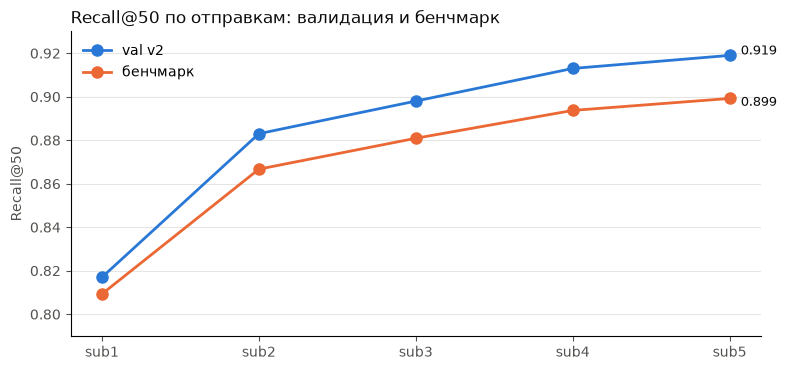

In [5]:
steps = pd.DataFrame([
    ("sub1", "BM25 + локационный приор", 0.817, 0.8093),
    ("sub2", "+ e5-small, LightGBM над кандидатами", 0.883, 0.8667),
    ("sub3", "+ дообученная e5-base", 0.898, 0.8809),
    ("sub4", "+ гео-признаки, кандидаты без сильного приора", 0.913, 0.8937),
    ("sub5", "+ профиль кликов, косинус e5-small", 0.919, 0.8992),
], columns=["пресет", "изменение", "val v2", "бенчмарк"])
display(steps)

fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(steps))
for col, color, dx in [("val v2", BLUE, -0.03), ("бенчмарк", ORANGE, 0.03)]:
    ax.plot(x, steps[col], color=color, lw=2, marker="o", ms=8, label=col)
    ax.annotate(f"{steps[col].iloc[-1]:.3f}", (x[-1], steps[col].iloc[-1]), xytext=(8, -3 if dx > 0 else 3),
                textcoords="offset points", color=INK, fontsize=9, va="center")
ax.set_xticks(x, steps["пресет"])
ax.set_ylabel("Recall@50", color=MUTED)
ax.set_ylim(0.79, 0.93)
ax.grid(axis="y", color="#e6e5e1", lw=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, loc="upper left")
ax.set_title("Recall@50 по отправкам: валидация и бенчмарк", loc="left", color=INK)
plt.tight_layout()

Разрыв «val v2 → бенчмарк» стабилен (0.008–0.02) на всех пяти отправках — валидация честно предсказывает результат.

Абляции на val v2 (`experiments/01…06, 10`):

| Шаг | Recall@50 |
|---|---|
| BM25 без нормализации / стемминг / **лемматизация** / + заголовок×3 | 0.363 / 0.425 / 0.430 / **0.452** (val v1) |
| + локационный приор (w = 0.5 / 1 / **2** / 4 / жёсткий фильтр) | 0.761 / 0.842 / **0.870** / 0.843 / 0.813 (val v1) |
| эмбеддинги + локация: e5-small → дообученная e5-base | 0.749 → 0.840 |
| фьюжн BM25 + эмбеддинги + локация: e5-small → дообученная e5-base | 0.846 → 0.874 |
| ранкер: все признаки / без статичных признаков объявления (e5-small) | 0.884 / 0.883 |
| ранкер (ft) + гео / + кандидаты без приора / **+ оба** | 0.908 / 0.901 / **0.913** |
| + ансамбль e5-small / + профиль кликов / **+ оба** (среднее по 3 сидам) | 0.913 / 0.917 / **0.919** |
| cross-encoder (RuBERT, дообученный) вторым уровнем — **отвергнут** | 0.9135 (без прироста) |

## 5. Анализ ошибок и найденные ловушки

**Где терялись релевантные объявления** (конфигурация sub3, `experiments/07_error_analysis.py`): 3.9% не попадали в кандидаты (из них у 87.5% «чужая» локация), 6.5% были среди кандидатов, но ниже 50-го места.

| Сегмент запросов | доля запросов | Recall@50 (sub3) | доля потерь | Recall@50 (sub5) |
|---|---|---|---|---|
| поиск по региону | 15% | 0.785 | 32% | 0.828 |
| мегаполисы (>10k объявлений) | 17% | 0.813 | 31% | 0.840 |
| остальные города | 68% | ~0.94 | 37% | — |

* **Регион** → гео-признаки (расстояние до «центра» региона, нормированное на его радиус) и отдельный источник кандидатов без сильного приора локации.
* **Мегаполисы** — сотни похожих объявлений; у 68% вытесненных позитивов ни один отдельный скор не ставил их в top-50 (`experiments/09_megacity.py`). Помог «профиль кликов» похожих запросов; cross-encoder и расширение обучающей выборки ранкера — нет (кривая обучения выходит на плато после ~1800 запросов, `experiments/08_learning_curve.py`).

**Ловушки переноса val → бенчмарк**, которые пришлось обойти:
1. *История кликов объявления.* На val она есть у 49% корпуса (дистракторы взяты из train), на бенчмарке — у 10%. Признаки «объявление кликали раньше» не используются, а в профиле кликов вклад самого кандидата вычитается (leave-item-out).
2. *Источник объявления.* По статичным признакам (отзывы, цена, длина текста) объявление из train отличается от объявления бенчмарка с AUC 0.58; эти признаки исключены из ранкера (стоимость — 0.002 на val).
3. *Шум сидов.* Прирост меньше ~0.004 не отличим от шума; ключевые решения проверены на трёх сидах с парной оценкой ошибки.

**Отвергнутые гипотезы:** «промахи по локации — это удалённая работа» (7.2% против 6.6% — нет); «невиденные запросы хуже» (0.897 против 0.900 — нет); жёсткий фильтр по локации (хуже мягкого приора); cross-encoder вторым уровнем (без прироста).

## 6. Воспроизведение финального ответа

`predict.py` без аргументов = пресет `sub5`. Нужны дообученные модели в `models/` (см. `Readme.md`). С заполненным `cache/` занимает несколько минут.

In [6]:
res = subprocess.run([sys.executable, "predict.py", "--preset", "sub5", "--out", "answer.csv"], capture_output=True, text=True)
print(res.stdout[-300:] or res.stderr[-2000:])
print(subprocess.run([sys.executable, "check_answer.py", "answer.csv"], capture_output=True, text=True).stdout)
print("md5:", hashlib.md5(open("answer.csv", "rb").read()).hexdigest(), "(отправленный файл: eef81ade63922f3dd547a6bf18ead1e4)")
pd.read_csv("answer.csv", dtype=str).head(3)

preset sub5: {'method': 'ranker', 'dense': 'models/multilingual-e5-base-ft-full', 'dense_val': 'models/multilingual-e5-base-ft-val', 'fuse': '0.5,1.0,0.1', 'geo': True, 'noloc': 100, 'profile': True, 'extra_dense': ['intfloat/multilingual-e5-small']}
saved 2452 rows -> answer.csv



OK: 2452 rows, mean 50.0 items/row

md5: eef81ade63922f3dd547a6bf18ead1e4 (отправленный файл: eef81ade63922f3dd547a6bf18ead1e4)


,query_id,answer
0,70DfDUpwjxB4lzFd,b92ee8f432cec2d1 355392014208b7bf 4494aa11cbdc2d65 fa01652ca5f57d0f 9515d1e1...
1,JTrdTaZJvSiLPkXj,cbeccbecb1fb8d86 422d3ffdd5bbf626 367af128a9ea2a48 88931c4cd463d124 7e18adf2...
2,LZCZNoVG4AFUkVRJ,dab52187b4500d9b d62074dd39caefee d8fce513e4f000a7 3b370cc603f67947 168a9207...
